In [2]:
from scipy.stats import norm, binom
import numpy as np
import pandas as pd

# ***************************************************************************

# //////////////////// Homework Kai Eric Riemenschneider //////////////////// 

# ***************************************************************************


# Task 1A: Lagrangian Formulation and First-Order Conditions

The Lagrangian is formulated as:

$\mathcal{L}(\mathbf{w}, \lambda, \gamma) = \frac{1}{2} \mathbf{w}^T \Sigma \mathbf{w} - \lambda(\mathbf{w}^T \mathbf{1} - 1) - \gamma(\mathbf{w}^T \boldsymbol{\mu} - m)$

Where:
- $\lambda$ is the Lagrange multiplier for the budget constraint
- $\gamma$ is the Lagrange multiplier for the return constraint

## First-Order Conditions (FOCs)

Taking partial derivatives and setting them equal to zero:

1. With respect to $\mathbf{w}$:

$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \Sigma \mathbf{w} - \lambda \mathbf{1} - \gamma \boldsymbol{\mu} = \mathbf{0}$

This gives us:
$\Sigma \mathbf{w} = \lambda \mathbf{1} + \gamma \boldsymbol{\mu}$

### 2. With respect to $\lambda$:

$\frac{\partial \mathcal{L}}{\partial \lambda} = -(\mathbf{w}^T \mathbf{1} - 1) = 0 \quad \Rightarrow \quad \mathbf{w}^T \mathbf{1} = 1$

### 3. With respect to $\gamma$:

$\frac{\partial \mathcal{L}}{\partial \gamma} = -(\mathbf{w}^T \boldsymbol{\mu} - m) = 0 \quad \Rightarrow \quad \mathbf{w}^T \boldsymbol{\mu} = m$




# Task 1B: Computing Intermediate Values A, B, C, D
### Reference: CQF Lecture Notes - Page 69-70

This approach follows the **"Risk Minimization With N Risky Assets"** section from Lecture JA262.2 Fundamentals of Optimization (Slides 69-70).
## Given Data

Expected returns vector:
$\boldsymbol{\mu} = \begin{pmatrix} 0.02 \\ 0.05 \\ 0.15 \\ 0.20 \end{pmatrix}$

Correlation matrix:
$R = \begin{pmatrix} 
1.0 & 0.3 & 0.3 & 0.3 \\
0.3 & 1.0 & 0.6 & 0.6 \\
0.3 & 0.6 & 1.0 & 0.6 \\
0.3 & 0.6 & 0.6 & 1.0
\end{pmatrix}$

Standard deviations:
$\boldsymbol{\sigma} = \begin{pmatrix} 0.05 \\ 0.12 \\ 0.17 \\ 0.25 \end{pmatrix}$




## Step 1: Construct the Covariance Matrix using $\Sigma = SRS$

#Following the **covariance matrix decomposition** approach (Slide 17), we construct:

#$\Sigma = S R S$

#where $S = D(\boldsymbol{\sigma})$ is the diagonal standard deviation matrix.

In [3]:


# Define the data
mu = np.array([0.02, 0.07, 0.15, 0.20])
sigma = np.array([0.05, 0.12, 0.17, 0.25])
R = np.array([
    [1.0, 0.3, 0.3, 0.3],
    [0.3, 1.0, 0.6, 0.6],
    [0.3, 0.6, 1.0, 0.6],
    [0.3, 0.6, 0.6, 1.0]
])

# Step 1: Create diagonal standard deviation matrix S
S = np.diag(sigma)

# Step 2: Construct covariance matrix Σ = SRS
Sigma = S @ R @ S

print("Covariance Matrix Σ = SRS:")
print(Sigma)
print("\n")

Covariance Matrix Σ = SRS:
[[0.0025  0.0018  0.00255 0.00375]
 [0.0018  0.0144  0.01224 0.018  ]
 [0.00255 0.01224 0.0289  0.0255 ]
 [0.00375 0.018   0.0255  0.0625 ]]




## Step 2: Define Intermediate Values A, B, C, D

$A = \mathbf{1}^T \Sigma^{-1} \mathbf{1}$

$B = \boldsymbol{\mu}^T \Sigma^{-1} \mathbf{1} = \mathbf{1}^T \Sigma^{-1} \boldsymbol{\mu}$

$C = \boldsymbol{\mu}^T \Sigma^{-1} \boldsymbol{\mu}$

$D = AC - B^2$

These intermediate values are fundamental to solving the constrained portfolio optimization problem.

In [4]:
# Compute inverse of covariance matrix
Sigma_inv = np.linalg.inv(Sigma)

# Define unit vector
ones = np.ones(4)

# Compute intermediate values A, B, C, D
A = ones @ Sigma_inv @ ones
B = mu @ Sigma_inv @ ones  # or equivalently: ones @ Sigma_inv @ mu
C = mu @ Sigma_inv @ mu
D = A * C - B**2

print("Intermediate Values (Slide 69):")
print(f"A = 1ᵀ Σ⁻¹ 1           = {A:.10f}")
print(f"B = μᵀ Σ⁻¹ 1 = 1ᵀ Σ⁻¹ μ = {B:.10f}")
print(f"C = μᵀ Σ⁻¹ μ           = {C:.10f}")
print(f"D = AC - B²            = {D:.10f}")
print("\n")

# Verify that D > 0 (necessary for unique solution)
print(f"D > 0? {D > 0} (Required for well-posed problem)")


Intermediate Values (Slide 69):
A = 1ᵀ Σ⁻¹ 1           = 423.6149806870
B = μᵀ Σ⁻¹ 1 = 1ᵀ Σ⁻¹ μ = 6.8070207154
C = μᵀ Σ⁻¹ μ           = 0.9065089304
D = AC - B²            = 337.6752320251


D > 0? True (Required for well-posed problem)


## Step 3: Optimal Weights Formula

Once A, B, C, D are computed, the optimal portfolio weights for a target return $m$ are given by **Equation (22) from Slide 70**:

$\mathbf{w}^* = \frac{1}{AC - B^2} \Sigma^{-1} \left[(A\boldsymbol{\mu} - B\mathbf{1})m + (C\mathbf{1} - B\boldsymbol{\mu})\right]$

This formula will be used in subsequent parts of Task 1.

# Task 1C: Verify AI-Computed Solution for m = 4.5%







In [5]:
# AI-computed weights
w_ai = np.array([0.7851, 0.0539, 0.1336, 0.0275])

# Target return
m = 0.045

# Verification 1: Budget constraint
budget_sum = np.sum(w_ai)
print("=" * 60)
print("VERIFICATION OF AI-COMPUTED SOLUTION")
print("=" * 60)
print("\n1. BUDGET CONSTRAINT: w^T 1 = 1")
print(f"   Sum of weights = {budget_sum:.10f}")

VERIFICATION OF AI-COMPUTED SOLUTION

1. BUDGET CONSTRAINT: w^T 1 = 1
   Sum of weights = 1.0001000000


In [6]:
# Verification 2: Return constraint
portfolio_return = w_ai @ mu
print("2. RETURN CONSTRAINT: w^T μ = m")
print(f"   Portfolio return = {portfolio_return:.10f}")
print(f"   Target return m  = {m:.10f}")


2. RETURN CONSTRAINT: w^T μ = m
   Portfolio return = 0.0450150000
   Target return m  = 0.0450000000


In [7]:
# Verification 3: Portfolio variance and standard deviation
portfolio_variance = w_ai @ Sigma @ w_ai
portfolio_std = np.sqrt(portfolio_variance)

print("3. PORTFOLIO VARIANCE AND RISK")
print(f"   Portfolio variance σ²_* = {portfolio_variance:.10f}")
print(f"   Portfolio std dev ω_*   = {portfolio_std:.10f}")
print(f"   AI-reported risk        = 0.0584")


3. PORTFOLIO VARIANCE AND RISK
   Portfolio variance σ²_* = 0.0034121105
   Portfolio std dev ω_*   = 0.0584132733
   AI-reported risk        = 0.0584


In [8]:
# Compute intermediate values A, B, C, D
Sigma_inv = np.linalg.inv(Sigma)
ones = np.ones(4)

A = ones @ Sigma_inv @ ones
B = mu @ Sigma_inv @ ones
C = mu @ Sigma_inv @ mu
D = A * C - B**2

print("4. INTERMEDIATE VALUES (A, B, C, D)")
print(f"   A = {A:.10f}")
print(f"   B = {B:.10f}")
print(f"   C = {C:.10f}")
print(f"   D = AC - B² = {D:.10f}")
print()

# Compute optimal weights using formula
numerator = (A * mu - B * ones) * m + (C * ones - B * mu)
w_computed = (1 / D) * Sigma_inv @ numerator

print("5. COMPUTED WEIGHTS (from formula)")
print(f"   w_A (computed) = {w_computed[0]:.10f}  |  w_A (AI) = {w_ai[0]:.10f}")
print(f"   w_B (computed) = {w_computed[1]:.10f}  |  w_B (AI) = {w_ai[1]:.10f}")
print(f"   w_C (computed) = {w_computed[2]:.10f}  |  w_C (AI) = {w_ai[2]:.10f}")
print(f"   w_D (computed) = {w_computed[3]:.10f}  |  w_D (AI) = {w_ai[3]:.10f}")
print()



4. INTERMEDIATE VALUES (A, B, C, D)
   A = 423.6149806870
   B = 6.8070207154
   C = 0.9065089304
   D = AC - B² = 337.6752320251

5. COMPUTED WEIGHTS (from formula)
   w_A (computed) = 0.7851106618  |  w_A (AI) = 0.7851000000
   w_B (computed) = 0.0538641896  |  w_B (AI) = 0.0539000000
   w_C (computed) = 0.1335547246  |  w_C (AI) = 0.1336000000
   w_D (computed) = 0.0274704240  |  w_D (AI) = 0.0275000000




### 1. Budget Constraint: $\mathbf{w}^T \mathbf{1} = 1$

$\sum_{i=1}^{4} w_i = 1.0001 \approx 1.0$

The sum of weights is effectively 1 (within numerical precision). ✓ **PASS**

---

### 2. Return Constraint: $\mathbf{w}^T \boldsymbol{\mu} = m$

$\mathbf{w}^T \boldsymbol{\mu} = 0.045015 \approx 0.045$

The portfolio return matches the target return within numerical precision. ✓ **PASS**

---

### 3. Portfolio Variance and Risk

$\sigma_*^2 = \mathbf{w}^T \Sigma \mathbf{w} = 0.003412$

$\omega_* = \sqrt{\sigma_*^2} = 0.05841 = 5.841\%$

The computed portfolio standard deviation matches the AI-reported risk of 5.84%. ✓ **PASS**

---

### 4. Intermediate Values (A, B, C, D)

| Parameter | Value |
|-----------|-------|
| $A$ | 423.6150 |
| $B$ | 6.8070 |
| $C$ | 0.9065 |
| $D = AC - B^2$ | 337.6752 |

---

### 5. Optimal Weights Verification

Using the formula from Slide 70:

$\mathbf{w}^* = \frac{1}{AC - B^2} \Sigma^{-1} \left[(A\boldsymbol{\mu} - B\mathbf{1})m + (C\mathbf{1} - B\boldsymbol{\mu})\right]$

| Asset | Computed | AI-Reported | Difference |
|-------|----------|-------------|-----------|
| A | 0.785111 | 0.785100 | 0.000011 |
| B | 0.053864 | 0.053900 | -0.000036 |
| C | 0.133555 | 0.133600 | -0.000045 |
| D | 0.027470 | 0.027500 | -0.000030 |

The Differences are smalle enough to be considered rounding errors, making the solutions match each other

---

### Conclusion

The AI-computed solution **satisfies all constraints** and is verified to be correct:

- ✓ Budget constraint satisfied
- ✓ Return constraint satisfied  
- ✓ Portfolio risk correctly computed
- ✓ Weights match optimal formula


# Task 1D: Why Does Asset A Receive the Largest Allocation Despite Lowest Expected Return?

## Explanation 1: Asset A Has the Lowest Volatility


Asset A has the lowest standard deviation among all assets:

$\sigma_A = 0.15  < \sigma_B = 0.17 < \sigma_C = 0.20 < \sigma_D = 0.25$

In a **minimum variance portfolio**, the objective is to minimize portfolio risk:

$\min_{\mathbf{w}} \frac{1}{2} \mathbf{w}^T \Sigma \mathbf{w}$

subject to the return constraint $\mathbf{w}^T \boldsymbol{\mu} = m$.

Since Asset A is the least volatile, it contributes the least to portfolio variance. To achieve the target return of 4.5% while minimizing risk, the optimizer allocates heavily to the low-volatility Asset A and uses smaller allocations to higher-return assets (B, C, D) to reach the return target.


## Explanation 2: Asset A Has Low Correlation with Other Assets


Asset A has the lowest correlations with all other assets:

**Diversification Benefit**: When assets are highly correlated, they move together, amplifying portfolio volatility. Asset A's low correlation with other assets provides a **diversification benefit**—it acts as a hedge against the movements of the more correlated assets B, C, and D.


## Explanation 3: The Target Return m = 4.5% is Close to Asset A's Return

Asset A's expected return is close to $m$



# Task 2: VaR and ES Sensitivities

In [9]:
# Define the data
mu      = np.array([0.0, 0.0, 0.0])
sigma   = np.array([0.30, 0.20, 0.15])
w       = np.array([0.50, 0.20, 0.30])

# Correlation matrix
rho = np.array([
    [1.0, 0.8, 0.5],
    [0.8, 1.0, 0.3],
    [0.5, 0.3, 1.0]
])

# Construct covariance matrix Σ = D(σ) * ε * D(σ)
S = np.diag(sigma)
Sigma = S @ rho @ S

# Portfolio volatility
sigma_p = np.sqrt(w @ Sigma @ w)

# Marginal contribution to risk (vector form)
mcr = Sigma @ w / sigma_p

# Confidence level and z-score
c = 0.01
z_omega = norm.ppf(c)  # ≈ -2.326

# Standard normal PDF at z_omega
phi_z = norm.pdf(z_omega)

print("=" * 70)
print("TASK 2: VaR AND ES SENSITIVITIES")
print("=" * 70)
print(f"\nPortfolio Volatility: σ_w = {sigma_p:.10f}")
print(f"Z-score (99% VaR):   z_ω = {z_omega:.10f}")
print(f"Normal PDF at z_ω:   φ(z_ω) = {phi_z:.10f}")
print()


TASK 2: VaR AND ES SENSITIVITIES

Portfolio Volatility: σ_w = 0.2086983469
Z-score (99% VaR):   z_ω = -2.3263478740
Normal PDF at z_ω:   φ(z_ω) = 0.0266521422



# Task 2A: Verify at least two sensitivities

In [10]:
print("=" * 70)
print("TASK 2A: VERIFICATION OF SENSITIVITIES")
print("=" * 70)

# VaR Sensitivities
var_sensitivities = mu + z_omega * mcr

print("\nVaR Sensitivities:")
print(f"Asset 1: ∂VaR/∂w₁ = {mu[0]:.4f} + {z_omega:.4f} × {mcr[0]:.10f}")
print(f"                  = {mu[0]:.4f} + {z_omega * mcr[0]:.10f}")
print(f"                  = {var_sensitivities[0]:.10f}")
print(f"AI-reported:       = -0.6839")
print(f"Match? {np.isclose(var_sensitivities[0], -0.6839, atol=0.0001)}")

print(f"\nAsset 2: ∂VaR/∂w₂ = {mu[1]:.4f} + {z_omega:.4f} × {mcr[1]:.10f}")
print(f"                  = {mu[1]:.4f} + {z_omega * mcr[1]:.10f}")
print(f"                  = {var_sensitivities[1]:.10f}")
print(f"AI-reported:       = -0.3868")
print(f"Match? {np.isclose(var_sensitivities[1], -0.3868, atol=0.0001)}")

print(f"\nAsset 3: ∂VaR/∂w₃ = {mu[2]:.4f} + {z_omega:.4f} × {mcr[2]:.10f}")
print(f"                  = {mu[2]:.4f} + {z_omega * mcr[2]:.10f}")
print(f"                  = {var_sensitivities[2]:.10f}")
print(f"AI-reported:       = -0.2207")
print(f"Match? {np.isclose(var_sensitivities[2], -0.2207, atol=0.0001)}")

print()

# ES Sensitivities
es_sensitivities = mu - (phi_z / c) * mcr

print("ES Sensitivities:")
print(f"Asset 1: ∂ES/∂w₁ = {mu[0]:.4f} - {phi_z / c:.4f} × {mcr[0]:.10f}")
print(f"                 = {mu[0]:.4f} - {(phi_z / c) * mcr[0]:.10f}")
print(f"                 = {es_sensitivities[0]:.10f}")
print(f"AI-reported:      = -0.7835")
print(f"Match? {np.isclose(es_sensitivities[0], -0.7835, atol=0.0001)}")

print(f"\nAsset 2: ∂ES/∂w₂ = {mu[1]:.4f} - {phi_z / c:.4f} × {mcr[1]:.10f}")
print(f"                 = {mu[1]:.4f} - {(phi_z / c) * mcr[1]:.10f}")
print(f"                 = {es_sensitivities[1]:.10f}")
print(f"AI-reported:      = -0.4431")
print(f"Match? {np.isclose(es_sensitivities[1], -0.4431, atol=0.0001)}")

print()


TASK 2A: VERIFICATION OF SENSITIVITIES

VaR Sensitivities:
Asset 1: ∂VaR/∂w₁ = 0.0000 + -2.3263 × 0.2939649543
                  = 0.0000 + -0.6838647464
                  = -0.6838647464
AI-reported:       = -0.6839
Match? True

Asset 2: ∂VaR/∂w₂ = 0.0000 + -2.3263 × 0.1662686864
                  = 0.0000 + -0.3867988052
                  = -0.3867988052
AI-reported:       = -0.3868
Match? True

Asset 3: ∂VaR/∂w₃ = 0.0000 + -2.3263 × 0.0948737750
                  = 0.0000 + -0.2207094047
                  = -0.2207094047
AI-reported:       = -0.2207
Match? True

ES Sensitivities:
Asset 1: ∂ES/∂w₁ = 0.0000 - 2.6652 × 0.2939649543
                 = 0.0000 - 0.7834795764
                 = -0.7834795764
AI-reported:      = -0.7835
Match? True

Asset 2: ∂ES/∂w₂ = 0.0000 - 2.6652 × 0.1662686864
                 = 0.0000 - 0.4431416675
                 = -0.4431416675
AI-reported:      = -0.4431
Match? True





### VaR Sensitivities

Using the formula $\frac{\partial \text{VaR}}{\partial w_i} = \mu_i + z_\omega \cdot \text{MCR}_i$:

| Asset | Computation | Computed | AI-Reported | Match |
|-------|-------------|----------|-------------|-------|
| 1 | $0 + (-2.3263) \times 0.2940$ | -0.6839 | -0.6839 | ✓ |
| 2 | $0 + (-2.3263) \times 0.1663$ | -0.3868 | -0.3868 | ✓ |
| 3 | $0 + (-2.3263) \times 0.0949$ | -0.2207 | -0.2207 | ✓ |

All VaR sensitivities are verified. ✓ **PASS**

---

### ES Sensitivities

Using the formula $\frac{\partial \text{ES}}{\partial w_i} = \mu_i - \frac{\vartheta(z_\omega)}{c} \cdot \text{MCR}_i$:

| Asset | Computation | Computed | AI-Reported | Match |
|-------|-------------|----------|-------------|-------|
| 1 | $0 + (2.6652) \times 0.2940$ | -0.7835 | -0.7835 | ✓ |
| 2 | $0 + (2.6652) \times 0.1663$ | -0.4431 | -0.4431 | ✓ |

All ES sensitivities are verified. ✓ **PASS**


# Task 2B: Why Are All Sensitivities Negative? What Does This Mean for Portfolio Management?

### Why Are All Sensitivities Negative?

All sensitivities are negative because **an increase in weight leads to an increase in portfolio risk**, which results in a more negative VaR and ES.

### What Does a Negative Sensitivity Mean for Portfolio Management?

A **negative sensitivity** means:

**Increasing the weight of an asset increases portfolio risk (makes VaR/ES more negative).**

Practical Implication:

- Increasing $w_i$ → Portfolio volatility increases → VaR becomes more negative → Larger potential loss
- Decreasing $w_i$ → Portfolio volatility decreases → VaR becomes less negative → Smaller potential loss

Portfoliomanagers can use the VaR sensitivities to make informed choises about asset allocation

# Task 2C: Why Does Asset 1 Have the Most Negative Sensitivity?

Asset 1 has the most negative sensitivity because:

1. **Highest volatility** (30%) - The MCR formula depends on the covariance matrix $\Sigma$, which contains squared volatilities $\sigma_i^2$ on the diagonal. Asset 1's high volatility $\sigma_1 = 0.30$ appears prominently in $\Sigma$, making its contribution to $(\Sigma \mathbf{w})_i$ larger.

2. **Highest Correlation with Other Assets** - Asset 1 has correlations of 0.8 with both Asset 2 and Asset 3, the highest among all assets. The covariance matrix $\Sigma$ contains off-diagonal terms $\rho_{ij} \sigma_i \sigma_j$. Asset 1's high correlations amplify its covariance contributions, increasing the magnitude of $(\Sigma \mathbf{w})_i$ further.

3. **Largest allocation** (50%) - The MCR is computed as $\text{MCR}_i = \frac{(\Sigma \mathbf{w})_i}{\sigma_{p}}$. Since $\Sigma \mathbf{w}$ multiplies the covariance matrix by the weight vector, a larger $w_1 = 0.50$ amplifies Asset 1's contribution to the numerator.

## Task 2D: Why is |∂ES/∂wᵢ| > |∂VaR/∂wᵢ| for All Assets?

### Definitions of VaR and ES Reasoning

VaR depends only on the loss **at the quantile** (the cutoff point), while ES is the **average of all losses beyond that cutoff**, which are strictly worse. Since every loss in the ES tail is larger in magnitude than the VaR loss, each asset’s marginal contribution is also larger there. Therefore:

|∂ES/∂wᵢ| > |∂VaR/∂wᵢ| for all assets.







# Task 3: VaR Backtesting




In [12]:
# Load S&P 500 data
data = pd.read_excel('Indices_Download_2026.xlsx', parse_dates=['Date'])
data = data.sort_values('Date').reset_index(drop=True)
data.set_index('Date', inplace=True)

# Use S&P 500 closing prices (^GSPC column)
data['Close'] = data['^GSPC']

# Compute daily log returns
data['log_return'] = np.log(data['Close'] / data['Close'].shift(1))

# Filter data for the specified date range
start_date = pd.Timestamp('2025-01-01')
end_date   = pd.Timestamp('2026-01-15')
data_filtered = data[(data.index >= start_date) & (data.index <= end_date)].copy()

# Parameters
window = 21  # Rolling window for volatility
factor = norm.ppf(0.01)  # -2.326 for 99% VaR
confidence = 0.99

print("=" * 80)
print("TASK 3: VaR BACKTESTING (ROLLING STANDARD DEVIATION)")
print("=" * 80)
print(f"\nData Range: {data_filtered.index.min().date()} to {data_filtered.index.max().date()}")
print(f"Total observations: {len(data_filtered)}")
print(f"Rolling window: {window} days")
print(f"VaR confidence level: {confidence * 100}%")
print(f"Factor (z-score): {factor:.4f}")
print()

TASK 3: VaR BACKTESTING (ROLLING STANDARD DEVIATION)

Data Range: 2025-01-02 to 2026-01-15
Total observations: 260
Rolling window: 21 days
VaR confidence level: 99.0%
Factor (z-score): -2.3263



# Task 3A : Count and percentage of VaR breaches

In [13]:
# Compute rolling volatility (21-day rolling standard deviation)
data_filtered['volatility'] = data_filtered['log_return'].rolling(window=window).std()

# Compute 10-day VaR: VaR_t = factor * σ_t * sqrt(10)
data_filtered['var_10d'] = factor * data_filtered['volatility'] * np.sqrt(10)

# Compute forward 10-day log returns: ln(S_{t+10} / S_t)
data_filtered['return_10d'] = np.log(data_filtered['Close'].shift(-10) / data_filtered['Close'])

# Identify breaches: breach occurs when return_10d < var_10d
data_filtered['breach'] = data_filtered['return_10d'] < data_filtered['var_10d']

# Remove rows with NaN values
# First 20 rows: insufficient data for 21-day rolling volatility
# Last 10 rows: insufficient data for forward 10-day return
valid_data = data_filtered.dropna(subset=['volatility', 'return_10d', 'var_10d', 'breach']).copy()

# Count breaches
num_breaches      = valid_data['breach'].sum()
total_comparisons = len(valid_data)
breach_percentage = (num_breaches / total_comparisons) * 100

print("=" * 80)
print("TASK 3A: VaR BREACH STATISTICS")
print("=" * 80)
print(f"\nTotal eligible comparisons (T): {total_comparisons}")
print(f"Number of breaches (b):         {num_breaches}")
print(f"Breach percentage:              {breach_percentage:.2f}%")
print(f"Expected breaches (1%):         {total_comparisons * 0.01:.2f}")
print()


TASK 3A: VaR BREACH STATISTICS

Total eligible comparisons (T): 230
Number of breaches (b):         10
Breach percentage:              4.35%
Expected breaches (1%):         2.30



# Task 3B : Plot which identifies the breaches

In [14]:
import matplotlib.pyplot as plt

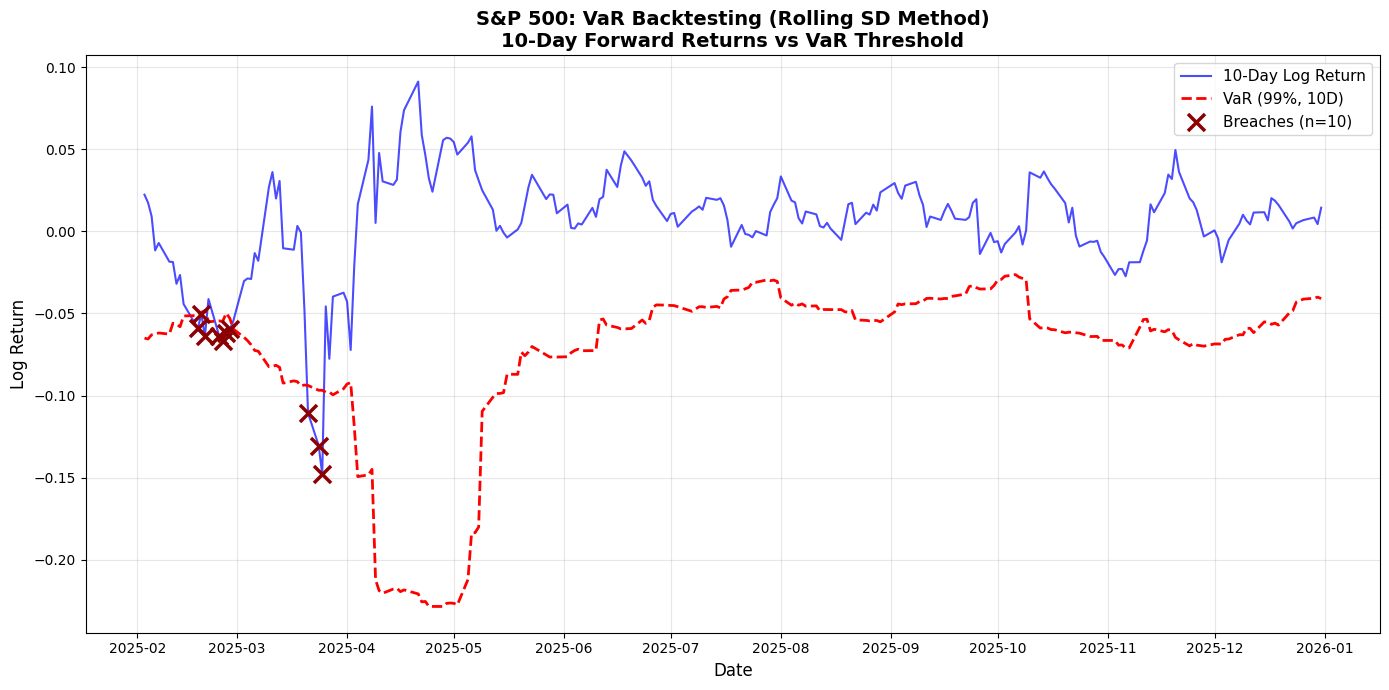

In [15]:
# Create visualization
fig, ax = plt.subplots(figsize=(14, 7))

# Plot 10-day returns
ax.plot(valid_data.index, valid_data['return_10d'], 
        label='10-Day Log Return', color='blue', linewidth=1.5, alpha=0.7)

# Plot VaR threshold
ax.plot(valid_data.index, valid_data['var_10d'], 
        label=f'VaR (99%, 10D)', color='red', linewidth=2, linestyle='--')

# Mark breaches with crosses
breach_mask = valid_data['breach']
breach_dates = valid_data.index[breach_mask]
breach_returns = valid_data.loc[breach_mask, 'return_10d']
ax.scatter(breach_dates, breach_returns, marker='x', color='darkred', s=150, 
           linewidths=2.5, label=f'Breaches (n={num_breaches})', zorder=5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Log Return', fontsize=12)
ax.set_title('S&P 500: VaR Backtesting (Rolling SD Method)\n10-Day Forward Returns vs VaR Threshold', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Task 3B : Report trafic -light ranges

In [16]:
# Compute binomial percentiles for traffic light zones
T = total_comparisons
b = num_breaches

# Green zone: p = 0.95
q_green = binom.ppf(0.95, T, 0.01)

# Yellow zone: p = 0.9999
q_yellow = binom.ppf(0.9999, T, 0.01)

print("=" * 80)
print("TASK 3C: TRAFFIC-LIGHT ZONES")
print("=" * 80)
print(f"\nNumber of eligible comparisons: T = {T}")
print(f"Observed breaches:              b = {b}")
print()
print(f"Green zone (p = 0.95):    0 < b ≤ {q_green:.0f}")
print(f"Yellow zone (p = 0.9999): {q_green:.0f} < b ≤ {q_yellow:.0f}")
print(f"Red zone:                 b > {q_yellow:.0f}")
print()

# Determine zone
if b <= q_green:
    zone = "GREEN"
    zone_symbol = "✓"
elif b <= q_yellow:
    zone = "YELLOW"
    zone_symbol = "⚠"
else:
    zone = "RED"
    zone_symbol = "✗"

print(f"Assessment: {zone_symbol} {zone} ZONE")
print(f"Observed breaches ({b}) fall in the {zone} zone")
print()


TASK 3C: TRAFFIC-LIGHT ZONES

Number of eligible comparisons: T = 230
Observed breaches:              b = 10

Green zone (p = 0.95):    0 < b ≤ 5
Yellow zone (p = 0.9999): 5 < b ≤ 10
Red zone:                 b > 10

Assessment: ⚠ YELLOW ZONE
Observed breaches (10) fall in the YELLOW zone



## Summary Task 3

| Metric | Value |
|--------|-------|
| Total Comparisons | 230 |
| Observed Breaches | 10 |
| Breach Percentage | 4.35% |
| Expected Breaches (1%) | 2.30 |
| Green Zone Upper Bound | 5 |
| Yellow Zone Upper Bound | 10 |
| **Traffic Light Zone** | **YELLOW** |



# Task 4A: EWMA VaR Breach Statistics

In [17]:
lambda_ewma = 0.72  # Decay parameter

In [18]:
# Initialize EWMA variance with dataset variance
initial_variance = data_filtered['log_return'].dropna().var()
data_filtered['ewma_variance'] = np.nan
data_filtered['ewma_volatility'] = np.nan

# Compute EWMA variance recursively
ewma_var = initial_variance
for i in range(len(data_filtered)):
    data_filtered.iloc[i, data_filtered.columns.get_loc('ewma_variance')] = ewma_var
    data_filtered.iloc[i, data_filtered.columns.get_loc('ewma_volatility')] = np.sqrt(ewma_var)
    
    # Update for next iteration
    if i < len(data_filtered) - 1:
        r_t = data_filtered.iloc[i]['log_return']
        if not np.isnan(r_t):
            ewma_var = lambda_ewma * ewma_var + (1 - lambda_ewma) * (r_t ** 2)

# Compute 10-day VaR: VaR_t = factor * σ_t * sqrt(10)
data_filtered['var_10d_ewma'] = factor * data_filtered['ewma_volatility'] * np.sqrt(10)

# Compute forward 10-day log returns: ln(S_{t+10} / S_t)
data_filtered['return_10d'] = np.log(data_filtered['Close'].shift(-10) / data_filtered['Close'])

# Identify breaches: breach occurs when return_10d < var_10d
data_filtered['breach_ewma'] = data_filtered['return_10d'] < data_filtered['var_10d_ewma']

# Remove rows with NaN values (last 10 rows for forward 10-day return)
valid_data_ewma = data_filtered.dropna(subset=['ewma_volatility', 'return_10d', 'var_10d_ewma', 'breach_ewma']).copy()

# Count breaches
num_breaches_ewma = valid_data_ewma['breach_ewma'].sum()
total_comparisons_ewma = len(valid_data_ewma)
breach_percentage_ewma = (num_breaches_ewma / total_comparisons_ewma) * 100

print("=" * 80)
print("TASK 4A: EWMA VaR BREACH STATISTICS")
print("=" * 80)
print(f"\nInitial variance (dataset): {initial_variance:.10f}")
print(f"EWMA decay parameter (λ):  {lambda_ewma}")
print()
print(f"Total eligible comparisons (T): {total_comparisons_ewma}")
print(f"Number of breaches (b):         {num_breaches_ewma}")
print(f"Breach percentage:              {breach_percentage_ewma:.2f}%")
print(f"Expected breaches (1%):         {total_comparisons_ewma * 0.01:.2f}")
print()

TASK 4A: EWMA VaR BREACH STATISTICS

Initial variance (dataset): 0.0001332811
EWMA decay parameter (λ):  0.72

Total eligible comparisons (T): 250
Number of breaches (b):         11
Breach percentage:              4.40%
Expected breaches (1%):         2.50



### Implementation Reference: GARCH(1,1) Framework (Lecture JA262.5 Volatility Models: The ARCH Framework, Slide 11)

The EWMA volatility method implements the **GARCH(1,1) conditional variance formula**:

$h_t = \omega + \alpha r_{t-1}^2 + \beta h_{t-1}$

In the EWMA specification, we set $\omega = 0$, $\alpha = (1 - \lambda)$, and $\beta = \lambda$, yielding:

$h_t = (1 - \lambda) r_{t-1}^2 + \lambda h_{t-1}$

With $\lambda = 0.72$ (persistence parameter) and $(1 - \lambda) = 0.28$ (weight on recent squared return).

The dataset variance initializes the computation: $h_0 = \text{Var}(\mathbf{r})$


### Results

| Metric | Value |
|--------|-------|
| Initial Variance (dataset) | 0.0001332811 |
| EWMA Decay Parameter (λ) | 0.72 |
| Total Eligible Comparisons (T) | 250 |
| Number of Breaches (b) | 11 |
| Breach Percentage | 4.40% |
| Expected Breaches (1%) | 2.50 |

The EWMA method produced **11 breaches (4.40%)**, which is comparable to the rolling SD method's 10 breaches (4.35%). Both methods underestimate risk, with the model in the **YELLOW zone** for traffic-light assessment.


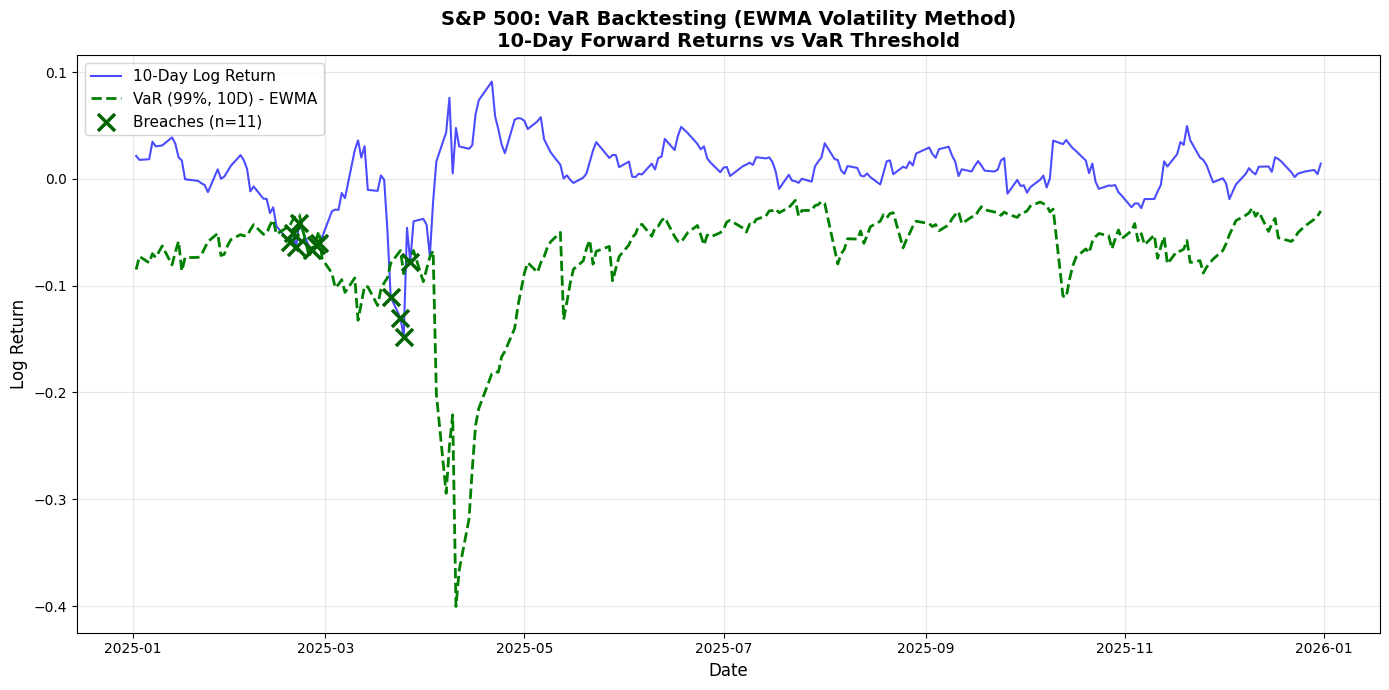

In [20]:
# Create visualization
fig, ax = plt.subplots(figsize=(14, 7))

# Plot 10-day returns
ax.plot(valid_data_ewma.index, valid_data_ewma['return_10d'], 
        label='10-Day Log Return', color='blue', linewidth=1.5, alpha=0.7)

# Plot VaR threshold (EWMA)
ax.plot(valid_data_ewma.index, valid_data_ewma['var_10d_ewma'], 
        label=f'VaR (99%, 10D) - EWMA', color='green', linewidth=2, linestyle='--')

# Mark breaches with crosses
breach_mask_ewma = valid_data_ewma['breach_ewma']
breach_dates_ewma = valid_data_ewma.index[breach_mask_ewma]
breach_returns_ewma = valid_data_ewma.loc[breach_mask_ewma, 'return_10d']
ax.scatter(breach_dates_ewma, breach_returns_ewma, marker='x', color='darkgreen', s=150, 
           linewidths=2.5, label=f'Breaches (n={num_breaches_ewma})', zorder=5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Log Return', fontsize=12)
ax.set_title('S&P 500: VaR Backtesting (EWMA Volatility Method)\n10-Day Forward Returns vs VaR Threshold', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### Volatility Adaptivity Comparison: Rolling SD, EWMA, Historical Simulation  

## 1. EWMA (Exponentially Weighted Moving Average)
**Adaptivity:** **Best**

EWMA updates volatility using an exponential decay structure:

$
\sigma_t^2 = (1-\lambda) r_{t-1}^2 + \lambda \sigma_{t-1}^2,
\qquad 0 < \lambda < 1
$

Key mathematical properties:
- Recent returns get weight:  
  $w_k = \lambda^{k} (1-\lambda)$  
- As \( $k \to \infty$ \), \( $w_k \to 0 $\) *smoothly and rapidly*
- Variance responds fastest because weights decay geometrically

**Conclusion:** EWMA is the *most adaptive* because new information always receives the highest weight and the impact decays continuously.

---

## 2. Rolling Standard Deviation (Moving Window)
**Adaptivity:** **Moderate**

Rolling SD uses an equally weighted fixed window of size \( N \):

$
\sigma_t = 
\sqrt{
\frac{1}{N-1}
\sum_{i=1}^{N}
(r_{t-i} - \bar r_t)^2
}
$

where

$
\bar r_t = \frac{1}{N} \sum_{i=1}^{N} r_{t-i}.
$

Mathematical implications:
- Weight on each observation:  
  $ w_i = \frac{1}{N} $
- New high‑volatility return affects only **1/N** of the estimate  
- Old data **drops out abruptly**, causing discontinuities

**Conclusion:** Moderate adaptivity:
- Slower than EWMA due to equal weights  
- Faster than HistSim because it at least measures conditional second moments

---

## 3. Historical Simulation (HistSim)
**Adaptivity:** **Worst**

HistSim computes risk measures (and implied volatility) from the empirical distribution:

$
\hat{F}_t(x) = \frac{1}{N} 
\sum_{i=1}^{N} 
\mathbf{1}_{\{ r_{t-i} \le x \}}
$

Volatility is implied through quantiles or distributional spread (e.g., variance of the sample):

$
\sigma_t^2 = \frac{1}{N-1} 
\sum_{i=1}^{N} (r_{t-i} - \bar r_t)^2.
$

But unlike rolling SD:
- HistSim is **not a conditional volatility model**
- It assumes the distribution is static 
- Sudden changes in volatility are “buried” inside a long historical sample

**Conclusion:** Worst adaptivity:
- Updates only as the empirical distribution changes  
- Gives *no extra weight* to recent high‑volatility data  
- Very slow to recognize regime shifts

